In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter

plt.style.use('seaborn-v0_8')

In [3]:
data = pd.read_csv('smaller.csv', dtype={'SOCP': str})
data['inc2024'] = data.PINCP * data.ADJINC / 1_000_000
print(data.shape, data.PWGTP.sum())

data = data.dropna(subset=['PWGTP', 'ADJINC', 'PINCP'])
print(data.shape, data.PWGTP.sum())

data = data[data.inc2024 > 0]
print(data.shape, data.PWGTP.sum())

(3422888, 7) 340110990
(2912790, 7) 280613270
(2556439, 7) 245168158


Text(0.5, 1.0, 'Distribution of personal income based on 2024 American Community Survey')

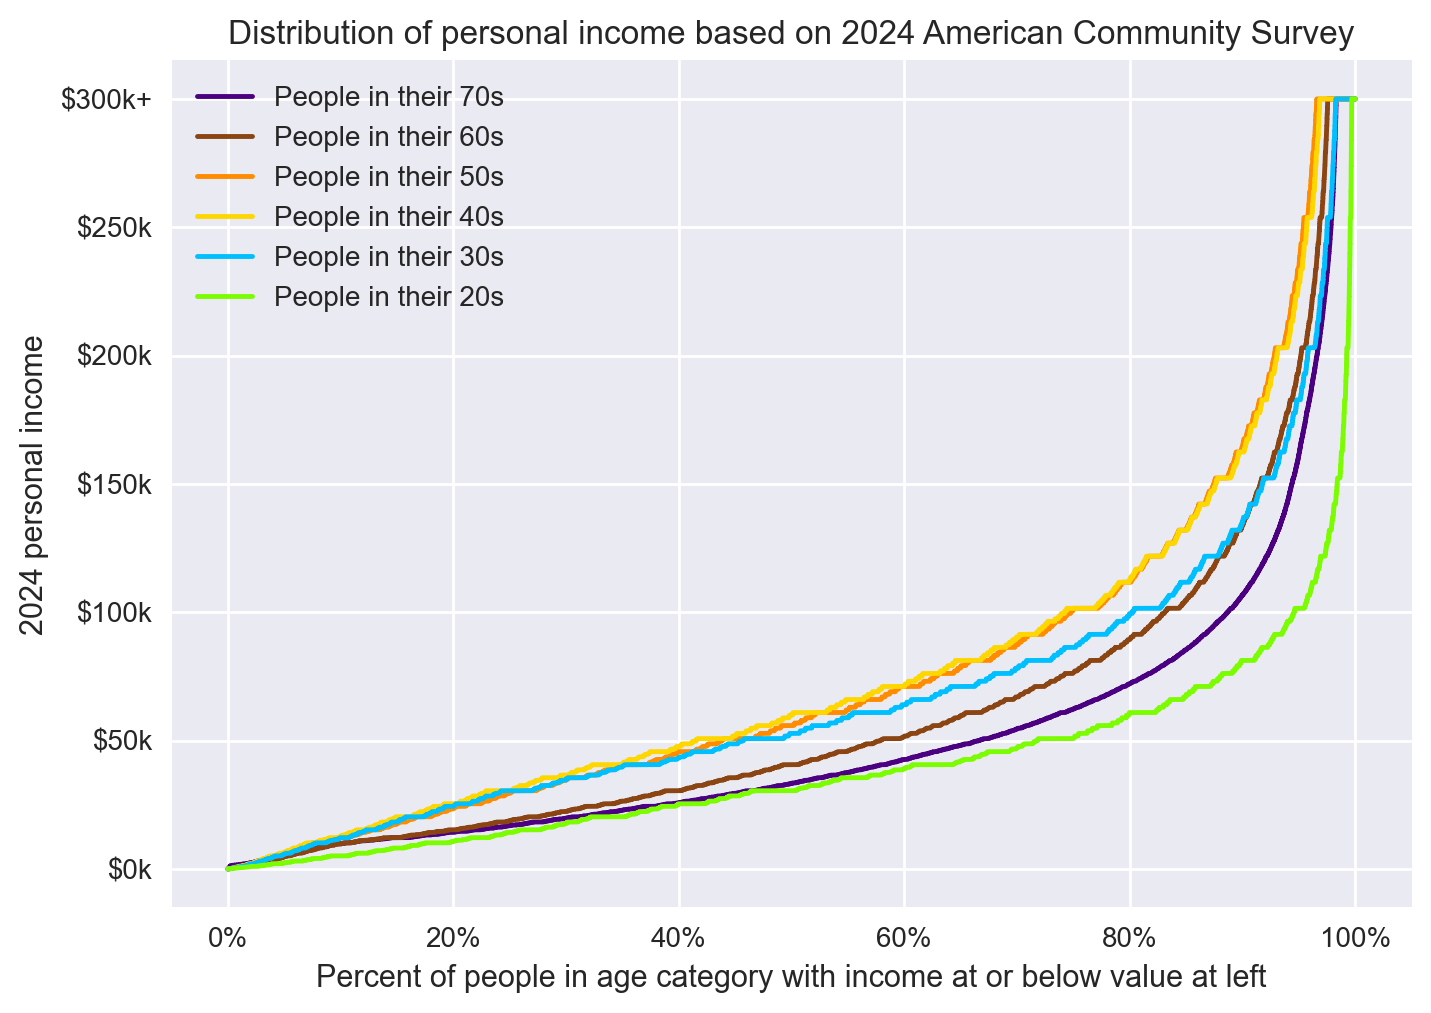

In [33]:
# cmap = plt.get_cmap('cividis')  # 'viridis', 'plasma', 'cividis', etc.
# colors = cmap(np.linspace(0, 1, 6))[::-1]

colors = [
        "#7CFC00",  # bright green (youth)
        "#00BFFF",  # sky blue
        "#FFD700",  # energetic yellow
        "#FF8C00",  # orange
        "#8B4513",  # brown
        "#4B0082",  # deep indigo (old age)
    ]

def fmtx(x, _):
    label = f'${int(x/1000)}k'
    if x == 300000:
        label += '+'
    return label

for index in reversed(range(6)):
    subset = data[data.AGEP // 10 == (index + 2)]
    subset = subset.sort_values('inc2024')
    subset['cum_people'] = subset.PWGTP.cumsum()
    total = subset.PWGTP.sum()
    plt.plot(subset.cum_people / total,
             subset.inc2024.clip(upper=300_000),
             color=colors[index],
             label=f'People in their {index + 2}0s')

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(fmtx))
plt.ylabel('2024 personal income')
plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.xlabel('Percent of people in age category with income at or below value at left')
plt.legend()
plt.title('Distribution of personal income based on 2024 American Community Survey')

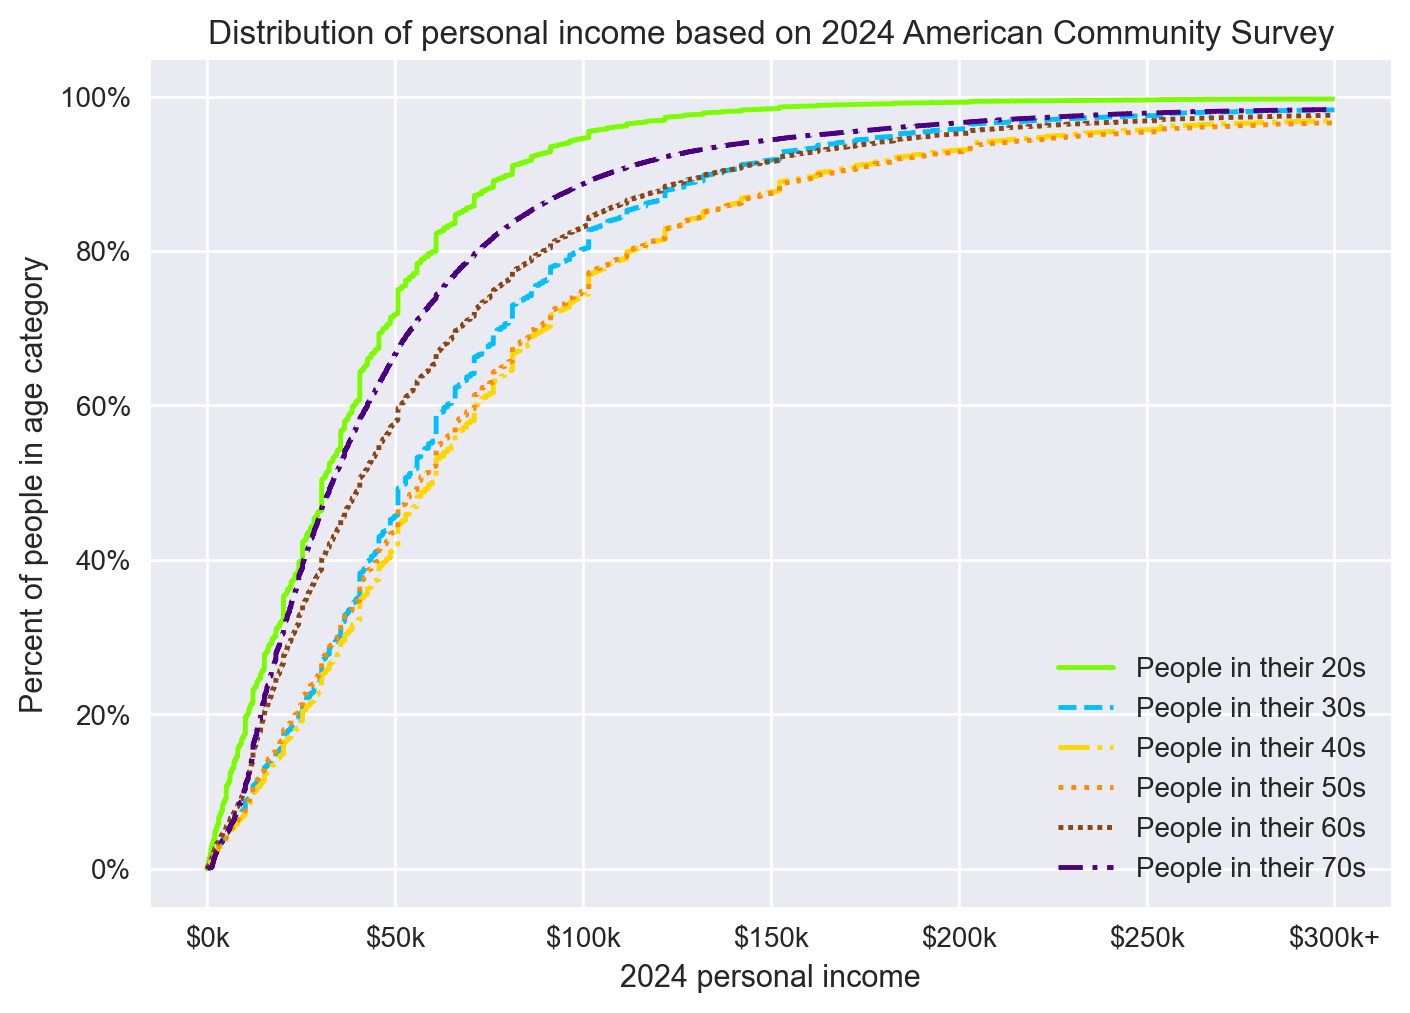

In [39]:
# cmap = plt.get_cmap('cividis')  # 'viridis', 'plasma', 'cividis', etc.
# colors = cmap(np.linspace(0, 1, 6))[::-1]

colors = [
        "#7CFC00",  # bright green (youth)
        "#00BFFF",  # sky blue
        "#FFD700",  # energetic yellow
        "#FF8C00",  # orange
        "#8B4513",  # brown
        "#4B0082",  # deep indigo (old age)
    ]

linestyles = [
    '-',                      # solid
    '--',                     # dashed
    '-.',                     # dash-dot
    ':',                      # dotted
    (0, (1, 1)),              # densely dotted
    (0, (5, 2, 1, 2)),        # dash-dot-dash (custom)
]

def fmtx(x, _):
    label = f'${int(x/1000)}k'
    if x == 300000:
        label += '+'
    return label

for index in range(6):
    subset = data[data.AGEP // 10 == (index + 2)]
    subset = subset.sort_values('inc2024')
    subset['cum_people'] = subset.PWGTP.cumsum()
    total = subset.PWGTP.sum()
    plt.plot(subset.inc2024[subset.inc2024 < 300_000],
             subset.cum_people[subset.inc2024 < 300_000] / total,
             color=colors[index],
             linestyle=linestyles[index],
             label=f'People in their {index + 2}0s')

plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(fmtx))
plt.xlabel('2024 personal income')
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.ylabel('Percent of people in age category')
plt.legend()
plt.title('Distribution of personal income based on 2024 American Community Survey')

plt.show()